device: cuda
step    0 | loss 1.913444
step  200 | loss 0.621473
step  400 | loss 0.587960
step  600 | loss 0.603338
step  800 | loss 0.636236
step 1000 | loss 0.787779
step 1200 | loss 0.529566
step 1400 | loss 0.607912
step 1600 | loss 0.491555
step 1800 | loss 0.587990
step 2000 | loss 0.501490
step 2200 | loss 0.562711
step 2400 | loss 0.635836
step 2600 | loss 0.655698
step 2800 | loss 0.469731
step 3000 | loss 0.463424
step 3200 | loss 0.645290
step 3400 | loss 0.497198
step 3600 | loss 0.647978
step 3800 | loss 0.611644
step 4000 | loss 0.592618
step 4200 | loss 0.535903
step 4400 | loss 0.517511
step 4600 | loss 0.565921
step 4800 | loss 0.454084


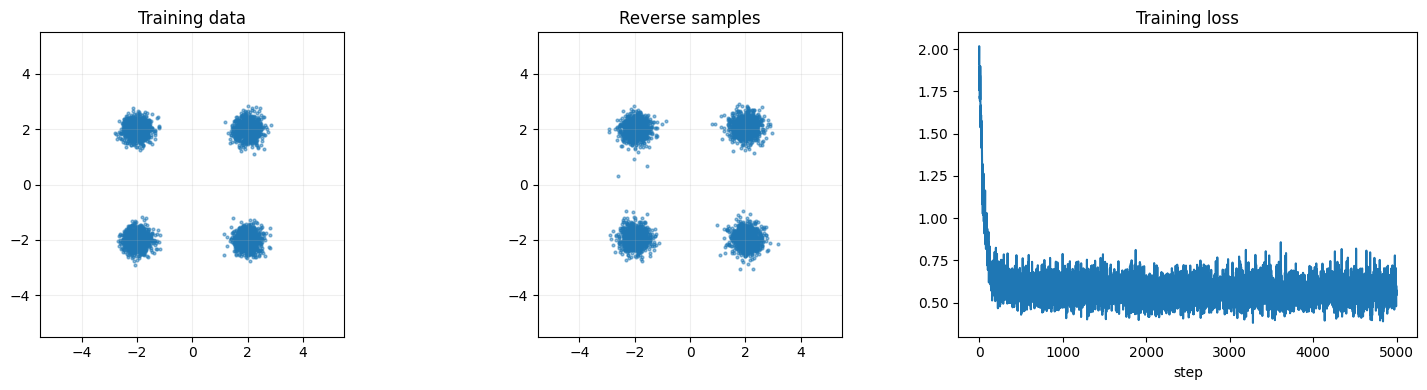

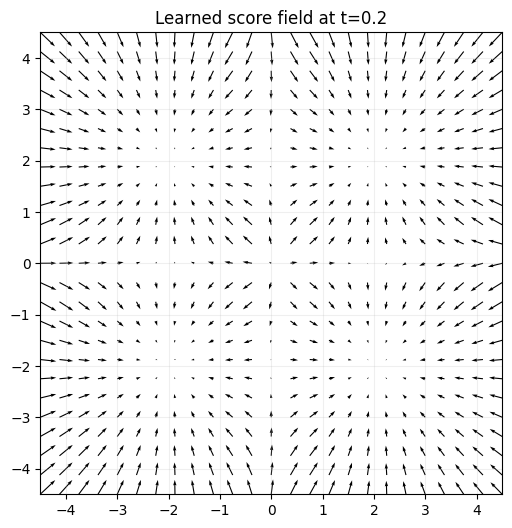

In [3]:
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Brownian diffusion model on a 2D Gaussian mixture
#
# Forward SDE:
#   dX_t = dW_t
#
# Forward marginal:
#   X_t | X_0 ~ N(X_0, t I)
#
# Direct conditional score:
#   grad_x log p_t(x | x0) = -(x - x0) / t
#
# Train score network directly:
#   s_theta(x, t) ≈ grad_x log p_t(x)
#
# Reverse SDE:
#   dX_t = - s_theta(X_t, t) dt + dW_bar
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)

# ------------------------------------------------------------
# 1) Data: 2D Gaussian mixture
# ------------------------------------------------------------
means = torch.tensor([
    [-2.0, -2.0],
    [-2.0,  2.0],
    [ 2.0, -2.0],
    [ 2.0,  2.0],
], dtype=torch.float32)

std_data = 0.25
num_modes = means.shape[0]

def sample_gmm(n: int) -> torch.Tensor:
    idx = torch.randint(0, num_modes, (n,))
    x = means[idx] + std_data * torch.randn(n, 2)
    return x

# ------------------------------------------------------------
# 2) Brownian forward process
# ------------------------------------------------------------
def brownian_forward_sample(x0: torch.Tensor, t: torch.Tensor):
    """
    Sample x_t from:
        x_t = x0 + sqrt(t) * z
    where z ~ N(0, I)

    Args:
        x0: (batch, dim)
        t:  (batch,)
    Returns:
        xt: (batch, dim)
    """
    t_col = t.unsqueeze(-1)  # (batch, 1)
    z = torch.randn_like(x0)
    xt = x0 + torch.sqrt(t_col) * z
    return xt

def conditional_score(xt: torch.Tensor, x0: torch.Tensor, t: torch.Tensor):
    """
    Direct conditional score:
        grad_x log p_t(x | x0) = -(x - x0) / t
    """
    t_col = t.unsqueeze(-1)
    return -(xt - x0) / t_col

# ------------------------------------------------------------
# 3) Score network s_theta(x, t)
# ------------------------------------------------------------
class ScoreNet(nn.Module):
    def __init__(self, hidden_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        # Use log(t) for better scale handling
        log_t = torch.log(t).unsqueeze(-1)
        inp = torch.cat([x, log_t], dim=-1)
        return self.net(inp)

# ------------------------------------------------------------
# 4) Train score directly
# ------------------------------------------------------------
def train_score_model(
    model: nn.Module,
    train_steps: int = 5000,
    batch_size: int = 512,
    lr: float = 2e-3,
    t_eps: float = 1e-4,
    T: float = 1.0,
):
    """
    Direct score-matching target:
        target_score = -(xt - x0)/t

    Weighted loss:
        E[ t * || s_theta(xt, t) - target_score ||^2 ]

    The factor t balances different noise levels.
    """
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []

    for step in range(train_steps):
        x0 = sample_gmm(batch_size).to(device)

        # sample t in (t_eps, T]
        t = torch.rand(batch_size, device=device) * (T - t_eps) + t_eps

        # forward perturbation
        xt = brownian_forward_sample(x0, t)

        # direct score target
        target_score = conditional_score(xt, x0, t)

        # model predicts the score directly
        pred_score = model(xt, t)

        # weighted direct score loss
        loss = (t.unsqueeze(-1) * (pred_score - target_score) ** 2).sum(dim=-1).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if step % 200 == 0:
            print(f"step {step:4d} | loss {loss.item():.6f}")

    return losses

# ------------------------------------------------------------
# 5) Reverse-time Euler-Maruyama sampling
# ------------------------------------------------------------
@torch.no_grad()
def sample_reverse_brownian(
    model: nn.Module,
    n_samples: int = 4000,
    n_steps: int = 1000,
    T: float = 1.0,
    eps: float = 1e-3,
):
    """
    Reverse SDE for forward dX_t = dW_t:

        dX_t = -s_theta(X_t, t) dt + dW_bar_t

    Simulate backward from T to eps using Euler-Maruyama.
    """
    model.eval()

    # crude prior at time T for this toy example
    x = torch.randn(n_samples, 2, device=device) * math.sqrt(T + 4.0)

    time_grid = torch.linspace(T, eps, n_steps + 1, device=device)

    for i in range(n_steps):
        t_now = time_grid[i]
        t_next = time_grid[i + 1]
        dt = t_next - t_now  # negative

        t_batch = torch.full((n_samples,), t_now, device=device)
        score = model(x, t_batch)

        # reverse drift
        x_mean = x + (-score) * dt

        if i < n_steps - 1:
            z = torch.randn_like(x)
            x = x_mean + math.sqrt(float(-dt)) * z
        else:
            x = x_mean

    return x.cpu()

# ------------------------------------------------------------
# 6) Optional: visualize score field at a fixed t
# ------------------------------------------------------------
@torch.no_grad()
def plot_score_field(model: nn.Module, t_value: float = 0.2, lim: float = 4.5, n_grid: int = 25):
    model.eval()

    xs = torch.linspace(-lim, lim, n_grid)
    ys = torch.linspace(-lim, lim, n_grid)
    X, Y = torch.meshgrid(xs, ys, indexing="xy")
    grid = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=-1).to(device)

    t = torch.full((grid.shape[0],), t_value, device=device)
    score = model(grid, t).cpu()

    U = score[:, 0].reshape(n_grid, n_grid)
    V = score[:, 1].reshape(n_grid, n_grid)

    plt.figure(figsize=(6, 6))
    plt.quiver(X.numpy(), Y.numpy(), U.numpy(), V.numpy())
    plt.title(f"Learned score field at t={t_value}")
    plt.xlim(-lim, lim)
    plt.ylim(-lim, lim)
    plt.gca().set_aspect("equal")
    plt.grid(alpha=0.2)
    plt.show()

# ------------------------------------------------------------
# 7) Plot results
# ------------------------------------------------------------
def plot_results(model: nn.Module, losses):
    real = sample_gmm(4000)
    fake = sample_reverse_brownian(model, n_samples=4000, n_steps=1000)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].scatter(real[:, 0], real[:, 1], s=4, alpha=0.5)
    axes[0].set_title("Training data")
    axes[0].set_aspect("equal")

    axes[1].scatter(fake[:, 0], fake[:, 1], s=4, alpha=0.5)
    axes[1].set_title("Reverse samples")
    axes[1].set_aspect("equal")

    axes[2].plot(losses)
    axes[2].set_title("Training loss")
    axes[2].set_xlabel("step")

    for ax in axes[:2]:
        ax.set_xlim(-5.5, 5.5)
        ax.set_ylim(-5.5, 5.5)
        ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 8) Main
# ------------------------------------------------------------
if __name__ == "__main__":
    print("device:", device)

    model = ScoreNet().to(device)

    losses = train_score_model(
        model,
        train_steps=5000,
        batch_size=512,
        lr=2e-3,
        t_eps=1e-4,
        T=1.0,
    )

    plot_results(model, losses)
    plot_score_field(model, t_value=0.2)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-ema-celebahq-256/snapshots/4cb6117472e6e4f45c5afe606b101858c27c3802: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-ema-celebahq-256/snapshots/4cb6117472e6e4f45c5afe606b101858c27c3802.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


saved step 0100
saved step 0200
saved step 0300
saved step 0400
saved step 0500
saved step 0600
saved step 0700
saved step 0800
saved step 0900
saved step 1000


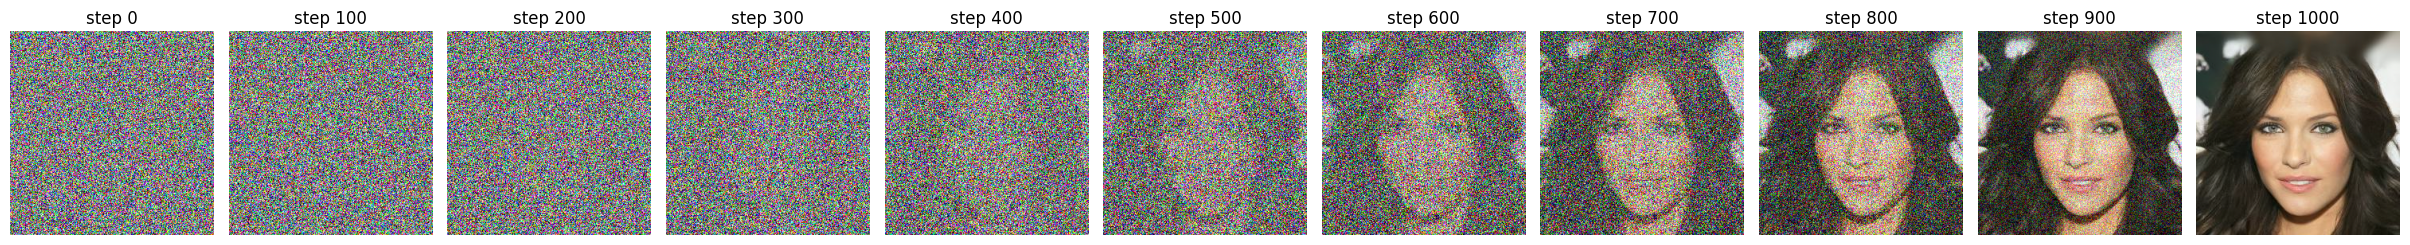

Done. Outputs saved in: celebahq256_ddpm_trajectory


In [1]:
import os
import math
import torch
import matplotlib.pyplot as plt

from diffusers import DDPMPipeline
from PIL import Image

# ------------------------------------------------------------
# DDPM sampling trajectory for:
#   google/ddpm-ema-celebahq-256
#
# Saves:
#   step_0000.png, step_0100.png, ..., step_1000.png
#   trajectory_strip.png
#
# It starts from pure Gaussian noise and manually runs
# 1000 DDPM denoising steps, saving an image every 100 steps.
# ------------------------------------------------------------

model_id = "google/ddpm-ema-celebahq-256"
num_inference_steps = 1000
save_every = 100
seed = 123
out_dir = "celebahq256_ddpm_trajectory"

os.makedirs(out_dir, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
generator = torch.Generator(device=device).manual_seed(seed)

# Load pipeline
pipe = DDPMPipeline.from_pretrained(model_id)
pipe = pipe.to(device)

unet = pipe.unet
scheduler = pipe.scheduler

# Set the number of denoising steps
scheduler.set_timesteps(num_inference_steps)

# Image shape from the model config
sample_size = unet.config.sample_size
in_channels = unet.config.in_channels

if isinstance(sample_size, int):
    height = width = sample_size
else:
    height, width = sample_size

# Start from pure Gaussian noise
x = torch.randn(
    (1, in_channels, height, width),
    generator=generator,
    device=device,
)

def tensor_to_pil(img_tensor: torch.Tensor) -> Image.Image:
    """
    Convert a tensor in roughly [-1, 1] to PIL for visualization.
    This clipping is mainly for display of intermediate steps.
    """
    img = (img_tensor.detach().cpu()[0] / 2 + 0.5).clamp(0, 1)
    img = img.permute(1, 2, 0).numpy()
    img = (img * 255).round().astype("uint8")
    return Image.fromarray(img)

saved_images = []

# Save step 0 = pure noise
img0 = tensor_to_pil(x)
img0.save(os.path.join(out_dir, "step_0000.png"))
saved_images.append((0, img0))

# Manual DDPM denoising loop
unet.eval()
with torch.no_grad():
    for step_idx, t in enumerate(scheduler.timesteps, start=1):
        # Predict noise
        model_output = unet(x, t).sample

        # DDPM update: x_t -> x_{t-1}
        x = scheduler.step(
            model_output=model_output,
            timestep=t,
            sample=x,
            generator=generator,
        ).prev_sample

        # Save every 100 steps and final step
        if step_idx % save_every == 0 or step_idx == num_inference_steps:
            img = tensor_to_pil(x)
            img.save(os.path.join(out_dir, f"step_{step_idx:04d}.png"))
            saved_images.append((step_idx, img))
            print(f"saved step {step_idx:04d}")

# Make a horizontal strip of saved images
n = len(saved_images)
fig, axes = plt.subplots(1, n, figsize=(2.2 * n, 2.8))

if n == 1:
    axes = [axes]

for ax, (step_num, pil_img) in zip(axes, saved_images):
    ax.imshow(pil_img)
    ax.set_title(f"step {step_num}")
    ax.axis("off")

plt.tight_layout()
strip_path = os.path.join(out_dir, "trajectory_strip.png")
plt.savefig(strip_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Done. Outputs saved in: {out_dir}")